# Tarea 2: Predicción de redshift fotométrico con métodos de ensamble

### Integrantes:
- Antonia Morales
- Martín Raffo

## Contexto

El redshift de una galaxia es una cantidad fundamental para estudiar distancias cosmológicas y evolución de galaxias. Idealmente, el redshift se mide mediante espectroscopía, pero obtener espectros para grandes muestras puede ser costoso en tiempo de observación.

Una alternativa ampliamente usada en astronomía es estimar redshifts fotométricos a partir de magnitudes medidas en distintos filtros. En esta actividad trabajaremos con un catálogo de galaxias que contiene fotometría multibanda y redshifts espectroscópicos de referencia. El objetivo será entrenar modelos de machine learning capaces de predecir el redshift usando información fotométrica.

La actividad se plantea como una competencia tipo **Kaggle**: cada grupo entrenará sus modelos con un conjunto de entrenamiento y deberá generar predicciones para un conjunto de test oculto. El ranking final se calculará usando el MSE sobre ese conjunto de test.

A diferencia del notebook que hicimos en clase (donde el dataset ya venía preparado), acá van a recibir el catálogo sin procesar. Van a tener que aplicar tú mismo/a las herramientas de diagnóstico que practicamos  (limpieza de datos, elección de modelo, optimización de hiperparámetros, comparación de criterios de feature importance) sin que nadie te diga de antemano qué decisiones tomar.

---

## Objetivo

Entrenar, comparar y optimizar modelos de regresión basados en árboles y métodos de ensamble para predecir el redshift de galaxias.

El criterio principal de evaluación será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm true},i})^2
$$

El objetivo práctico será obtener el menor MSE posible en el conjunto de test oculto.

---

## Datos

Se entregarán tres archivos:

1. `train_redshift.csv`: contiene las variables fotométricas y el redshift de referencia.
2. `test_redshift.csv`: contiene las mismas variables fotométricas, pero no incluye el redshift.
3. `sample_submission.csv`: muestra el formato esperado para la entrega de predicciones.

El archivo de entrenamiento contiene magnitudes corregidas por apertura en distintos filtros. El redshift de referencia está en la columna: $z_{\rm helio}$

En el archivo de test, esta columna no estará disponible.

---

## Instrucciones generales

Deben desarrollar un notebook reproducible en Python que incluya:

1. Exploración inicial del conjunto de entrenamiento.
2. Preparación de los datos para modelamiento.
3. Construcción o selección de variables predictoras.
4. Separación interna entre entrenamiento y validación, o uso de validación cruzada.
5. Entrenamiento de un modelo baseline con `DecisionTreeRegressor`.
6. Entrenamiento de algún método de ensamble, por ejemplo:

   * `RandomForestRegressor`
   * `ExtraTreesRegressor`
   * `GradientBoostingRegressor`
   * `HistGradientBoostingRegressor`
   * otro método justificado.
7. Optimización de hiperparámetros (puede usar GridSearchCV, RandomizedSearchCV, Optuna, etc)
8. Comparación de modelos usando MSE.
9. Selección del modelo final.
10. Generación de predicciones para `test_redshift.csv`.

El catálogo entregado no está completamente procesado. Parte del trabajo consiste en revisar valores faltantes, valores anómalos y decidir qué variables utilizar o construir.

El conjunto de test no contiene el redshift verdadero. Por lo tanto, no puede ser usado para evaluar ni ajustar modelos. La selección de modelos e hiperparámetros debe realizarse usando únicamente el conjunto de entrenamiento. Pueden crear un conjunto de validación interno (a partir del set de entrenamiento) para la optimización de hiperparámetros, pero el ranking final se calculará de forma ciega, evaluando sus predicciones directamente sobre test_redshift.csv

---

## Entrega de predicciones

Cada grupo debe entregar un archivo llamado:

```text
predicciones.csv
```

con exactamente dos columnas:

| objno_deep2 | z_pred |
| ----------- | ------ |
|             |        |
|             |        |
|             |        |

La columna `objno_deep2` debe coincidir con los identificadores del archivo `test_redshift.csv`.

La columna `z_pred` debe contener el redshift predicho por el modelo final.

El archivo debe tener una predicción para cada objeto del conjunto de test.

El archivo `sample_submission.csv` muestra el formato exacto que debe tener la entrega final. Deben reemplazar los valores de la columna `z_pred` por las predicciones de su modelo, manteniendo los mismos identificadores `objno_deep2`.

---
## Métricas de evaluación

La métrica principal de la competencia será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm spec},i})^2
$$

Además, deberán reportar dos métricas comúnmente usadas en estudios de redshifts fotométricos.

Primero, definimos el residuo normalizado:

$$
\Delta z_i = \frac{z_{{\rm spec},i} - z_{{\rm pred},i}}{1 + z_{{\rm spec},i}}
$$

La dispersión robusta de los residuos se calculará mediante la normalized median absolute deviation:

$$
\sigma_{\rm NMAD} = 1.48 \times {\rm median}\left(
\left| \Delta z_i - {\rm median}(\Delta z) \right|
\right)
$$

También se calculará la fracción de outliers:

$$
\eta = \frac{N_{\rm outliers}}{N}
$$

donde se considera outlier a todo objeto que cumple:

$$
\frac{|z_{\rm spec} - z_{\rm pred}|}{1 + z_{\rm spec}} > 0.15
$$

El ranking de la competencia se calculará usando el MSE sobre el conjunto de test oculto. Sin embargo, en el notebook deben reportar e interpretar las tres métricas: MSE, $\sigma_{\rm NMAD}$ y $\eta$.



## Resultado esperado en el notebook

El notebook debe incluir una tabla resumen similar a la siguiente:

| Modelo        | Features usadas | Hiperparámetros principales | MSE train | MSE validación |
| ------------- | --------------- | --------------------------- | --------- | -------------- |
| Decision Tree |                 |                             |           |                |
| Ensemble      |                 |                             |           |                |

Además, deben incluir:

* un gráfico de $z_{\rm true}$ vs. $z_{\rm pred}$ usando datos de validación
* un análisis de los errores del modelo
* un análisis de las métricas obtenidas
* una discusión sobre las variables más relevantes
* una conclusión justificando el modelo final escogido

---

## Preguntas finales
Respondan brevemente al final del notebook. En todas las preguntas, la respuesta debe apoyarse en gráficos o números específicos de su propio notebook, no en generalidades.

**Sobre la comparación de modelos:**

1. ¿Qué modelo obtuvo el menor MSE en validación?
2. ¿Ese modelo fue elegido como modelo final? Justifiquen.
3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?

**Sobre las variables:**

4. ¿Qué variables parecen ser más importantes para predecir el redshift?
5. Calculen la importancia de variables con al menos dos criterios distintos (por ejemplo, MDI y permutation importance). ¿Coinciden en el ranking? Si no coinciden, ¿a qué atribuyen la diferencia?

**Sobre los errores del modelo:**

6. ¿En qué rangos de redshift falla más el modelo?
7. En el notebook de clase vimos que los métodos basados en árboles tienden a "estrechar" la distribución de predicciones (sobreestiman z bajos, subestiman z altos). ¿Observan este mismo efecto en su propio scatter $z_{\rm true}$
 vs. $z_{\rm pred}$? ¿En qué rango es más pronunciado, y coincide con una menor cantidad de galaxias de entrenamiento en ese rango?
8. Si usaron oob_score en algún modelo, comparen ese valor con el de su validación cruzada. ¿Son consistentes? ¿Qué les dice eso sobre la confiabilidad de OOB para este dataset en particular?

**Sobre el proceso:**

9. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?
10. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?
11. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico? Justifiquen.


---

## Restricciones importantes

No se permite usar información externa al archivo entregado para predecir el redshift del conjunto de test.

No se debe modificar manualmente el archivo de predicciones para objetos individuales.

No se debe usar el conjunto de test para ajustar hiperparámetros ni tomar decisiones de modelamiento. El test oculto se usará solo para la evaluación final.

---

## Entregables

Cada grupo debe entregar:

1. Notebook reproducible en Python.
2. Archivo `predicciones.csv` con las predicciones para el conjunto de test.
3. Breve conclusión final dentro del notebook.

La evaluación considerará tanto el desempeño predictivo como la calidad del procedimiento. El notebook debe ser claro y explicativo del proceso.  El ranking se calculará usando el MSE sobre el conjunto de test oculto, pero la nota no dependerá únicamente del ranking.


In [ ]:
# librerías
import numpy as np
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Carga y exploración de los datos

Comenzamos cargando los datos ```"train_redshift.csv"``` y ```"test_redshift.csv"``` con las variables fotométricas.

In [ ]:
# carga de los datos train y test
train_data = pd.read_csv('train_redshift.csv')
test_data = pd.read_csv('test_redshift.csv')

Visualizamos el DataFrame con los datos de entrenamiento, para comprender qué columnas tiene y cómo está organizado.

In [ ]:
train_data # visualización

,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
0,13027624,214.812895,52.987945,1,25.536802,25.462694,25.331811,24.767236,24.867649,24.539227,0,0,-99,1.664840
1,12020064,214.693819,52.637015,4,23.802174,23.591218,23.290410,22.990565,23.018509,22.496892,0,0,0,1.314826
2,13035227,214.994798,53.051865,4,23.661166,22.389709,21.359927,20.786062,20.839287,20.466936,0,0,-99,0.297696
3,13039861,215.448870,53.106100,2,24.590983,23.872463,23.713001,23.670067,23.628797,23.663545,0,0,-99,1.159324
4,12004737,214.150124,52.436439,4,24.374535,24.226175,23.892377,23.263941,23.267458,22.990853,0,0,0,0.811566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19052,14017398,215.692246,53.437719,4,24.240796,24.205122,23.926456,23.528897,-99.000000,22.909429,0,1,-99,0.828503
19053,12005341,213.978285,52.419221,1,26.528255,25.084797,23.840316,23.301013,-99.000000,23.286571,0,1,1,0.373158
19054,11020060,213.900876,52.076499,1,23.596916,22.994620,22.683025,22.793867,-99.000000,22.622676,244,1,1,0.253488
19055,13032614,215.313935,53.052152,4,24.128220,23.855998,23.652930,23.422120,23.442838,23.146123,0,0,-99,1.449821


Observamos que el set de datos contiene información como la ID de cada objeto, coordenadas RA y DEC, las magnitudes según cada banda y su redshift asociado aplicada una corrección heliocéntrica ```zhelio```, además de otras variables fotométricas. Advertimos que la columna ```zquality``` parece dar cuenta de la calidad en la medida del redshift.

Para una mayor comprensión, utilizamos ```.info()```:

In [ ]:
train_data.info() # información general
print(f'Dimensiones del dataset: {train_data.shape[0]} objetos × {train_data.shape[1]} variables')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19057 entries, 0 to 19056
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   objno_deep2    19057 non-null  int64  
 1   ra_deep2       19057 non-null  float64
 2   dec_deep2      19057 non-null  float64
 3   zquality       19057 non-null  int64  
 4   u_apercor      19057 non-null  float64
 5   g_apercor      19057 non-null  float64
 6   r_apercor      19057 non-null  float64
 7   i_apercor      19057 non-null  float64
 8   i2_apercor     19057 non-null  float64
 9   z_apercor      19057 non-null  float64
 10  flag_cfhtls    19057 non-null  int64  
 11  cfhtls_source  19057 non-null  int64  
 12  subaru_source  19057 non-null  int64  
 13  zhelio         19057 non-null  float64
dtypes: float64(9), int64(5)
memory usage: 2.0 MB
Dimensiones del dataset: 19057 objetos × 14 variables


Observamos que para las 14 variables con 19057 objetos cada una, los datos no poseen ningún valor NaN, siendo todos ellos ```int64``` o ```float64``` según se indica.

In [ ]:
# verificamos que no hayan filas duplicadas
duplicated = train_data[train_data.duplicated(subset='objno_deep2', keep=False)]
print('Filas duplicadas:', duplicated)

Filas duplicadas: Empty DataFrame
Columns: [objno_deep2, ra_deep2, dec_deep2, zquality, u_apercor, g_apercor, r_apercor, i_apercor, i2_apercor, z_apercor, flag_cfhtls, cfhtls_source, subaru_source, zhelio]
Index: []


Nos cercioramos de que no existen filas duplicadas.

## 2. Preparación de los datos

### 2.1 Outliers

A modo de preparación de los datos, a continuación intentamos identificar posibles outliers en el dataset.

Dentro de los parámetros fotométricos, ```['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor']``` parecen corresponder a las magnitudes medidas en distintas bandas.

In [ ]:
# definimos variable con las bandas para análisis
bandas = ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor']

Como un primer paso, con ```.describe()``` obtenemos las principales estadísticas que presentan las bandas.

In [ ]:
train_data[bandas].describe().round(3) # overview de las principales estadísticas

,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor
count,19057.000,19057.000,19057.000,19057.000,19057.000,19057.000
mean,23.072,22.072,21.475,21.038,-22.944,20.809
std,21.589,20.739,20.671,20.668,59.776,20.660
min,-99.000,-99.000,-99.000,-99.000,-99.000,-99.000
25%,23.672,23.238,22.598,22.015,-99.000,21.711
50%,24.324,23.912,23.416,22.912,21.885,22.634
75%,25.003,24.440,23.897,23.498,23.243,23.295
max,99.000,99.000,99.000,99.000,99.000,99.000


De la tabla, se extrae información relevante para ambos datasets:

1. Observamos que el promedio es similar, rondando el ```~20```, a excepción de ```i2_apercor``` con un valor de ```-22.944```

2. Parece haber una gran desviación estándar

3. Los valores mínimo y máximo para todas las bandas corresponden a ```-99.000``` y  ```99.000``` respectivamente

4. La mediana ronda el ```~23```

Para una mejor visualización, realizamos un boxplot con los datos de entrenamiento:

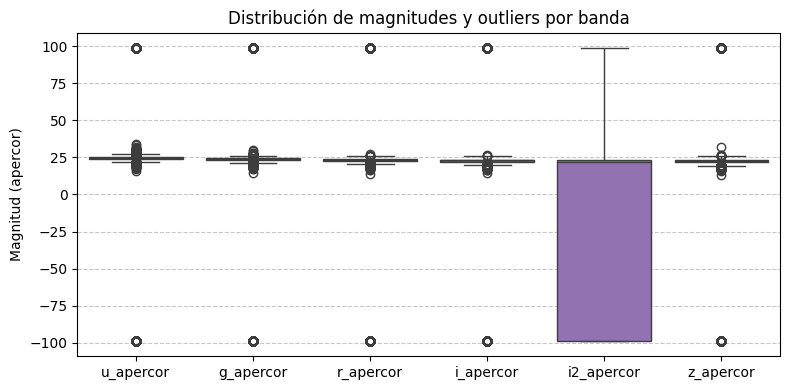

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=train_data[bandas]) # boxplot
plt.title('Distribución de magnitudes y outliers por banda')
plt.ylabel('Magnitud (apercor)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

El boxplot parece estar intentando ajustar su escala para incluir valores atípicos, lo que podría indicar que los valores mínimos y máximos corresponden a outliers o mediciones marcadas como error en el dataset. Observemos que sucede si reemplazamos esos valores por NaN:

In [ ]:
# reemplazamos por NaN
train_data.replace([-99.0, 99.0], np.nan, inplace=True)

In [ ]:
train_data[bandas].describe().round(3) # overview de las principales estadísticas (training set)

,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor
count,18222.000,18333.000,18336.000,18332.000,11708.000,18331.000
mean,24.363,23.776,23.167,22.696,22.784,22.454
std,1.208,1.073,1.123,1.185,1.206,1.229
min,15.846,14.737,14.126,14.362,16.387,13.338
25%,23.715,23.293,22.658,22.079,22.164,21.774
50%,24.325,23.919,23.424,22.923,23.000,22.645
75%,24.966,24.426,23.888,23.485,23.560,23.279
max,33.718,30.019,27.114,26.789,27.275,32.310


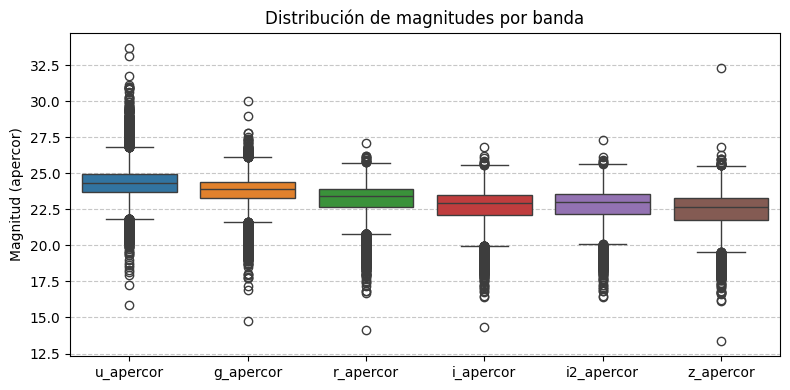

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=train_data[bandas]) # boxplot
plt.title('Distribución de magnitudes por banda')
plt.ylabel('Magnitud (apercor)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Extraemos lo siguiente:

1. Observamos que el promedio es similar en todas las bandas, rondando el ```~23```

2. La desviación estándar se redujo considerablemente

3. Los valores mínimo y máximo ya no son tan extremos en comparación

4. La mediana sigue rondando el ```~23```

### 2.2 Calidad de la medición del redshift

```zquality``` parece indicar la calidad con la que se midió el redshift. Inspeccionemos:

In [ ]:
train_data['zquality'].value_counts() # verificamos cantidad de valores según calidad

,count
zquality,
4,11589
2,2577
1,2556
3,1890
-2,230
-1,144
0,71


Observamos que se asigna una calidad según números del -2 al 4. Se toma una decisión importante para el análisis a partir de este punto: el trabajo principal de los datos considerará solo objetos con un ```zquality``` mayor o igual a 3.

In [ ]:
# seleccionamos objetos con calidad >=3
train_data_selection = train_data.loc[train_data['zquality'] >=3]

train_data_selection # visualización

,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
1,12020064,214.693819,52.637015,4,23.802174,23.591218,23.290410,22.990565,23.018509,22.496892,0.0,0.0,0.0,1.314826
2,13035227,214.994798,53.051865,4,23.661166,22.389709,21.359927,20.786062,20.839287,20.466936,0.0,0.0,NaN,0.297696
4,12004737,214.150124,52.436439,4,24.374535,24.226175,23.892377,23.263941,23.267458,22.990853,0.0,0.0,0.0,0.811566
5,14039099,215.907887,53.621584,4,24.035564,23.795731,23.463722,23.501204,NaN,22.882937,244.0,1.0,NaN,1.134533
6,14028856,215.683097,53.517474,3,23.793650,23.355886,22.923148,22.535669,NaN,22.046690,0.0,1.0,NaN,1.245617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19046,11052707,213.975771,52.378897,4,23.063735,22.935947,22.177762,21.950846,NaN,22.009886,0.0,1.0,1.0,0.515701
19048,12009120,214.076468,52.466746,3,23.847550,23.730496,23.579372,23.205144,23.191520,22.762498,252.0,0.0,0.0,1.105199
19052,14017398,215.692246,53.437719,4,24.240796,24.205122,23.926456,23.528897,NaN,22.909429,0.0,1.0,NaN,0.828503
19055,13032614,215.313935,53.052152,4,24.128220,23.855998,23.652930,23.422120,23.442838,23.146123,0.0,0.0,NaN,1.449821


### 2.3 Creación de nuevos features

En astronomía, no se suele trabajar con las magnitudes de cada banda de forma individual. En cambio, las magnitudes individuales se restan para extraer el color del objeto que se estudie. El uso del color es asociado a un análisis más aislado de la fuente, lo que reduce ruidos y encapsula las propiedades físicas. En el contexto de Machine Learning, realizar esta resta significaría la creación de nuevas features, donde la simplificación de la física que hay detrás de los datos podría beneficiar al modelo cuando tenga que ser entrenado.

In [ ]:
#obtención de colores

test_data["u-g"] = test_data["u_apercor"]-test_data["g_apercor"]
test_data["g-r"] = test_data["g_apercor"]-test_data["r_apercor"]
test_data["r-i"] = test_data["r_apercor"]-test_data["i_apercor"]
test_data["i-z"] = test_data["i_apercor"]-test_data["z_apercor"]
test_data["i2-z"] = test_data["i2_apercor"]-test_data["z_apercor"]

train_data["u-g"] = train_data["u_apercor"]-train_data["g_apercor"]
train_data["g-r"] = train_data["g_apercor"]-train_data["r_apercor"]
train_data["r-i"] = train_data["r_apercor"]-train_data["i_apercor"]
train_data["i-z"] = train_data["i_apercor"]-train_data["z_apercor"]
train_data["i2-z"] = train_data["i2_apercor"]-train_data["z_apercor"]

train_data_selection["u-g"] = train_data_selection["u_apercor"]-train_data_selection["g_apercor"]
train_data_selection["g-r"] = train_data_selection["g_apercor"]-train_data_selection["r_apercor"]
train_data_selection["r-i"] = train_data_selection["r_apercor"]-train_data_selection["i_apercor"]
train_data_selection["i-z"] = train_data_selection["i_apercor"]-train_data_selection["z_apercor"]
train_data_selection["i2-z"] = train_data_selection["i2_apercor"]-train_data_selection["z_apercor"]

/tmp/ipykernel_2022/2930643151.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data_selection["u-g"] = train_data_selection["u_apercor"]-train_data_selection["g_apercor"]
/tmp/ipykernel_2022/2930643151.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data_selection["g-r"] = train_data_selection["g_apercor"]-train_data_selection["r_apercor"]
/tmp/ipykernel_2022/2930643151.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

## 3. Selección de variables


Una vez finalizada la exploración y limpieza de los datos, procedemos con la selección de variables que entrenarán los modelos.

Como variables de entrenamiento se escogen las distintas magnitudes fotométricas según las bandas y los colores definidos previamente, y como variable de prueba los redshift heliocéntricos.

In [ ]:
# selección de columnas
cols = ['u_apercor', 'g_apercor', 'r_apercor',
        'i_apercor', 'i2_apercor', 'z_apercor', "u-g", "g-r", "i-z", "i2-z"]

X = train_data[cols]
y = train_data['zhelio'].values

In [ ]:
# selección de columnas con dataset corregido con calidad >=3
X_selection = train_data_selection[cols]
y_selection = train_data_selection['zhelio'].values

Luego, visualizamos el redshift en función de cada banda fotométrica:

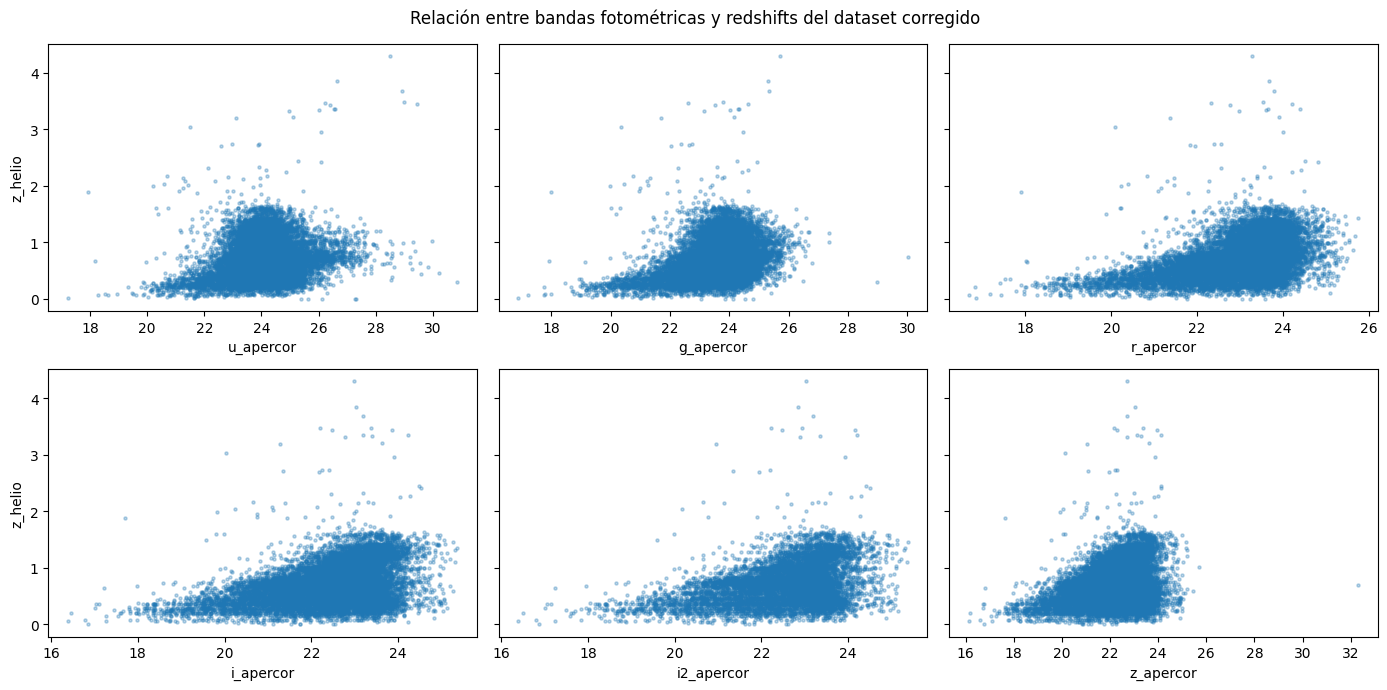

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, col in zip(axes.flat, bandas):
    ax.scatter(X_selection[col], y_selection, s=5, alpha=0.3)
    ax.set_xlabel(col)
axes[0, 0].set_ylabel('z_helio')
axes[1, 0].set_ylabel('z_helio')
plt.suptitle('Relación entre bandas fotométricas y redshifts del dataset corregido')
plt.tight_layout()
plt.show()

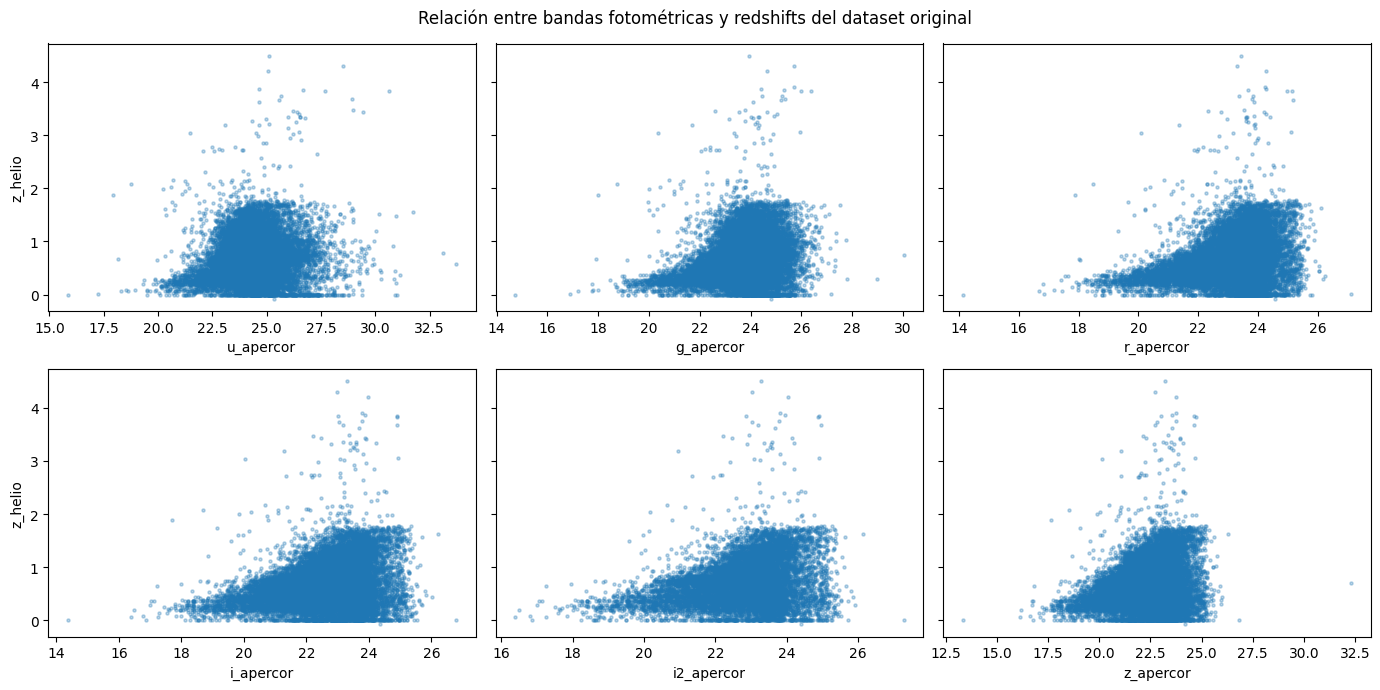

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, col in zip(axes.flat, cols):
    ax.scatter(X[col], y, s=5, alpha=0.3)
    ax.set_xlabel(col)
axes[0, 0].set_ylabel('z_helio')
axes[1, 0].set_ylabel('z_helio')
plt.suptitle('Relación entre bandas fotométricas y redshifts del dataset original')
plt.tight_layout()
plt.show()

## 4. Cross validation

Se opta por emplear una validación cruzada de tipo KFold con el objetivo de evitar sesgos de partición y un MSE más representativo.

In [ ]:
# preparando la cross-validation con KFold barajado
cv = KFold(shuffle = True, n_splits = 5, random_state=5)

# separación train y test para el eventual fit
X_train_selection, X_test_selection, y_train_selection, y_test_selection = train_test_split(X_selection, y_selection, test_size=0.2, random_state=42)

## 5. Entrenamiento del modelo baseline

Ya habiendo preparado los datos, procedemos a entrenar un modelo baseline. Como primera aproximación al uso de machine learning para abordar el problema de regresión, entrenamos un árbol de decisión cuyos hiperparámetros tienen valores arbitrarios.

In [ ]:
# entrenamos un árbol de decisión
model_tree = sklearn.tree.DecisionTreeRegressor(random_state=42, max_depth = 8, min_samples_split = 5, min_samples_leaf = 2)
model_tree.fit(X_train_selection, y_train_selection)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)

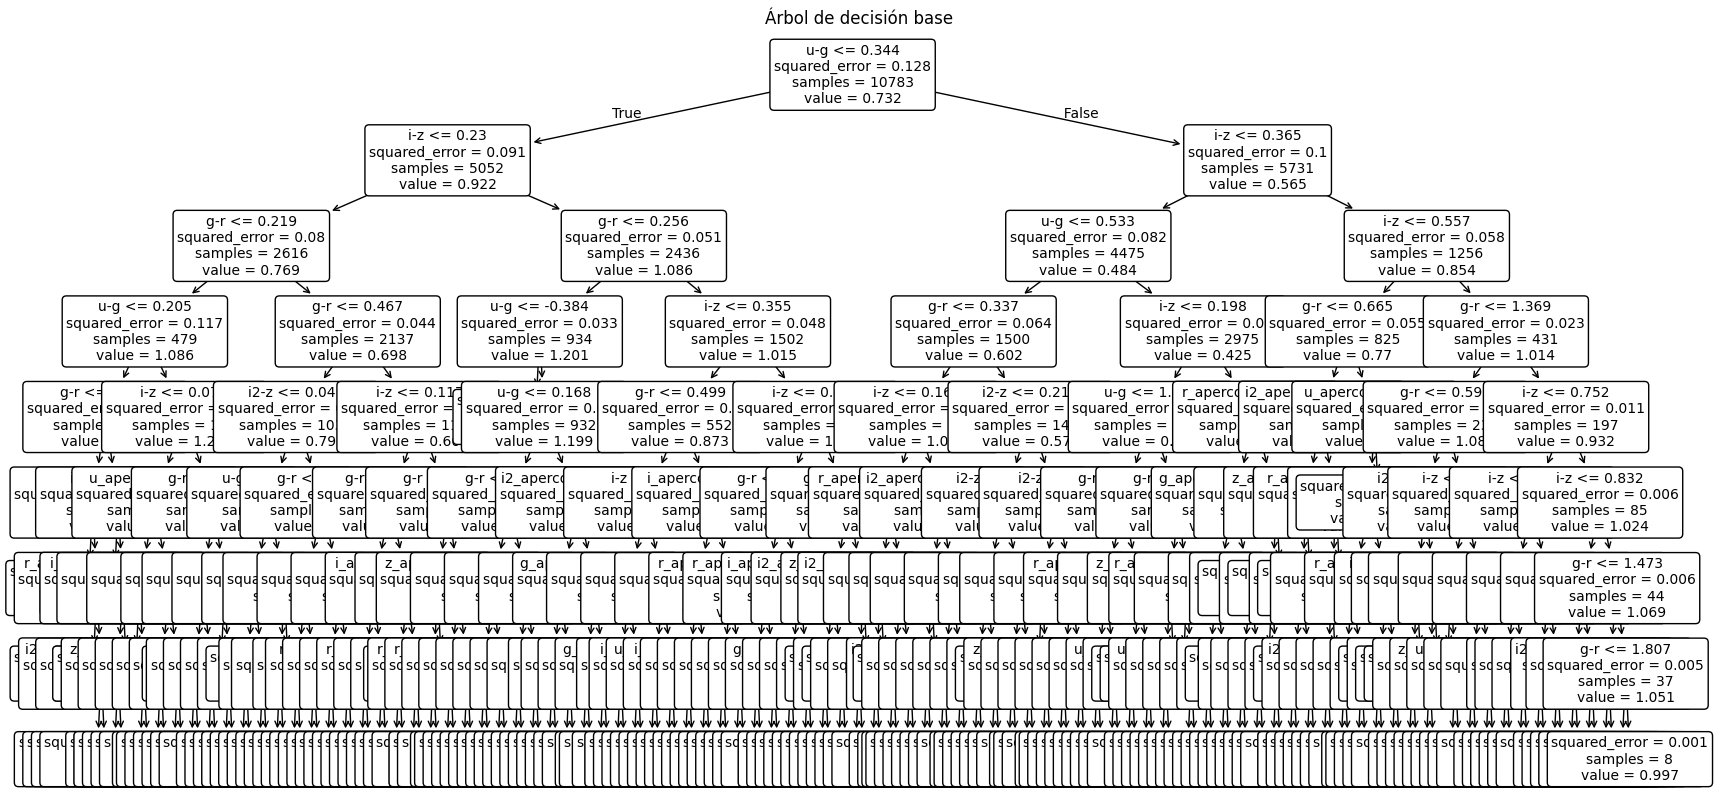

In [ ]:
# visualización del árbol

plt.figure(figsize=(20,10))
sklearn.tree.plot_tree(
    model_tree,
    feature_names=X.columns,
    filled=False,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

A continuación, calculamos MSE para los datos de entrenamiento y validación en el modelo baseline:

In [ ]:
scores_mse = cross_validate(
    model_tree,
    X_selection,
    y_selection,
    cv=cv,
    scoring='neg_mean_squared_error', return_train_score=True)

In [ ]:
mse_arbol_train = -scores_mse['train_score']
mse_arbol_test = -scores_mse['test_score']

In [ ]:
print(f"Árbol único, MSE promedio entrenamiento: {mse_arbol_train.mean():.4f}")
print(f"Árbol único, MSE promedio validación: {mse_arbol_test.mean():.4f}")

Árbol único, MSE promedio entrenamiento: 0.0270
Árbol único, MSE promedio validación: 0.0457


Los MSE reflejan un sobreajuste que se espera dada la complejidad del árbol, y considerando que no se le hizo ningún tipo de poda. Estos valores son importantes ya que serán el punto de referencia para la posterior comparación con el modelo de ensamble.

u-g           0.388077
i-z           0.325575
g-r           0.189680
i2-z          0.037370
r_apercor     0.024427
z_apercor     0.012288
i2_apercor    0.008873
u_apercor     0.008763
i_apercor     0.002526
g_apercor     0.002421
dtype: float64


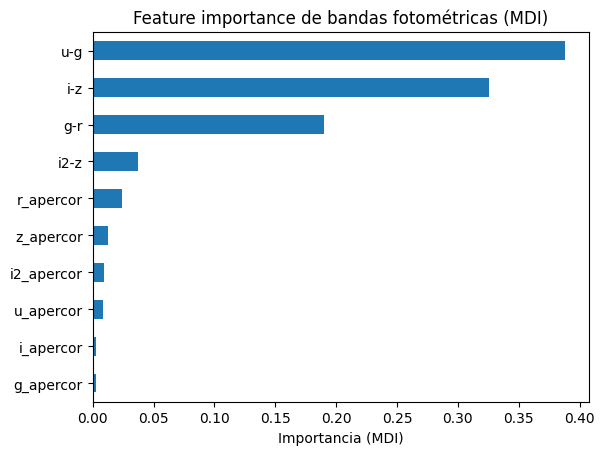

In [ ]:
# obtención de feature importance del árbol de decisión
importancias_tree = pd.Series(model_tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias_tree)

importancias_tree.plot(kind='barh')
plt.xlabel('Importancia (MDI)')
plt.title('Feature importance de bandas fotométricas (MDI)')
plt.gca().invert_yaxis()
plt.show()

Es interesante notar que, según el análisis, las variables más importantes son las creadas dentro del presente trabajo (los colores). Las bandas fotométricas, en tanto, pasan a segundo plano, con importancias menores a 0.05.

## 6. Método de ensamble

Con el objetivo de mejorar la calidad de la regresión, recurriremos a un método de ensamble. Optamos por un modelo tipo RandomForest.

In [ ]:
# entrenando el modelo
model_forest = sklearn.ensemble.RandomForestRegressor(n_estimators=200, random_state=42, max_depth=8)
model_forest.fit(X_train_selection, y_train_selection)

RandomForestRegressor(max_depth=8, n_estimators=200, random_state=42)

In [ ]:
# cross validation del modelo
scores_forest_mse = cross_validate(
    model_forest,
    X_selection,
    y_selection,
    cv=cv,
    scoring='neg_mean_squared_error', return_train_score=True)

In [ ]:
# obtención de métricas
mse_forest_train = -scores_forest_mse['train_score']
mse_forest_test = -scores_forest_mse['test_score']

In [ ]:
print(f"Random forest, MSE promedio entrenamiento: {mse_forest_train.mean():.4f}")
print(f"Random forest, MSE promedio validación: {mse_forest_test.mean():.4f}")

Random forest, MSE promedio entrenamiento: 0.0222
Random forest, MSE promedio validación: 0.0360


Luego, mediante MDI, obtenemos los features más importantes para el modelo.

u-g           0.380304
i-z           0.317930
g-r           0.185172
i2-z          0.040833
g_apercor     0.019355
r_apercor     0.014706
u_apercor     0.013190
i2_apercor    0.012959
i_apercor     0.007830
z_apercor     0.007722
dtype: float64


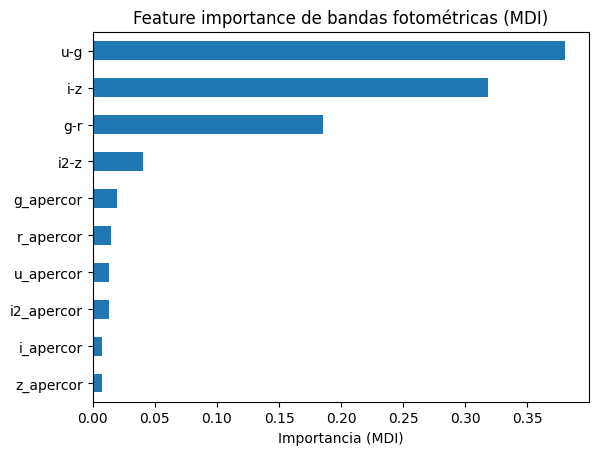

In [ ]:
importancias = pd.Series(model_forest.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias)

importancias.plot(kind='barh')
plt.xlabel('Importancia (MDI)')
plt.title('Feature importance de bandas fotométricas (MDI)')
plt.gca().invert_yaxis()
plt.show()

A partir del gráfico de feature importance podemos observar que los tres features más importantes dentro del dataset corresponden a los colores *u-g*, *i-z* y *g-r*.

## 7. Optimización de hiperparámetros

Para mejorar el modelo, debemos optimizar sus hiperparámetros; en el caso de RandomForest, estos son la cantidad de estimadores n_estimators, la profundidad máxima max_depth, la mínima cantidad de muestras requeridas para hacer un split min_samples_split y la cantidad mínima de muestras en una hoja min_samples_leaf. Por motivos de costo computacional, utilizaremos el módulo randomizer de scikit-learn.


In [ ]:
# optimizando mediante randomizer

params = {
    'n_estimators': [300, 400, 500],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [7, 8, 9],
    'min_samples_leaf': [4, 5, 6],
}

In [ ]:
randomizer = sklearn.model_selection.RandomizedSearchCV(model_forest, params, cv = 5,
                                                        scoring='neg_mean_squared_error', n_jobs = -1)

randomizer.fit(X_train_selection, y_train_selection)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(max_depth=8,
                                                   n_estimators=200,
                                                   random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 3, 5, 7],
                                        'min_samples_leaf': [4, 5, 6],
                                        'min_samples_split': [7, 8, 9],
                                        'n_estimators': [300, 400, 500]},
                   scoring='neg_mean_squared_error')

In [ ]:
# reporte de mejores parámetros para el randomizer
print(f"Best parameters: {randomizer.best_params_}")

# evaluar el mejor modelo
best_model_randomizer = randomizer.best_estimator_
print(f" MSE (training data):{metrics.mean_squared_error(y_train_selection, best_model_randomizer.predict(X_train_selection)):.4f}") #train score
print(f" MSE (validation data): {metrics.mean_squared_error(y_test_selection, best_model_randomizer.predict(X_test_selection)):.4f}") #test score

Best parameters: {'n_estimators': 500, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_depth': None}
 MSE (training data):0.0167
 MSE (validation data): 0.0308


## 8. Comparación de modelos

Recordamos los valores de MSE en datos de entrenamiento y validación, obtenidos para el árbol de decisión y el modelo Hist Gradient Boosting optimizado:

In [ ]:
print(f"Árbol único, MSE promedio entrenamiento: {mse_arbol_train.mean():.4f}")
print(f"Árbol único, MSE promedio validación: {mse_arbol_test.mean():.4f}")

print(f"Random Forest, MSE entrenamiento:{metrics.mean_squared_error(y_train_selection, best_model_randomizer.predict(X_train_selection)):.4f}") #train score
print(f"Random forest, MSE validación: {metrics.mean_squared_error(y_test_selection, best_model_randomizer.predict(X_test_selection)):.4f}") #test score

Árbol único, MSE promedio entrenamiento: 0.0270
Árbol único, MSE promedio validación: 0.0457
Random Forest, MSE entrenamiento:0.0167
Random forest, MSE validación: 0.0308


## 9. Selección del modelo final

Finalmente, después de haber realizado las evaluaciones de ambos modelos, seleccionamos como modelo definitivo a Random Forest. Esto principalmente por la considerable mejora en cuanto a la métrica MSE: el árbol de decisión individual obtuvo un MSE de 0.0457 en validación, lo que el método de ensamble redujo a 0.0308, mostrándose más preciso a la hora de estimar los redshift objetivo.  En cuanto a los errores de entrenamiento, el árbol individual presentó un valor de 0.0270, indicando un sobreajuste al compararlo con el error de validación. Junto con eso, el error de entrenamiento para RandomForest fue de 0.0167, un valor bastante bajo que refleja la memorización de la muestra, pero que se ve mitigado dada la utilización de subconjuntos aleatorios en el método con una capacidad de predicción sólida.

## 10. Generación de predicciones para test_redshift.csv

In [ ]:
z_pred = best_model_randomizer.predict(test_data[cols])
objno_deep2 = test_data['objno_deep2']

df_submissions = pd.DataFrame({'objno_deep2': objno_deep2, 'z_pred': z_pred})
df_submissions.to_csv('predicciones.csv', index=False)

# Análisis y conclusiones


Además, analizamos diversas métricas para evaluar la calidad de las predicciones:

In [ ]:
y_pred_validation = best_model_randomizer.predict(X_test_selection)
delta_z = (y_test_selection - y_pred_validation) / (1 + y_test_selection)
sigma_nmad = 1.48*np.median(np.abs(delta_z - np.median(delta_z)))
eta_outliers = np.mean(np.abs(delta_z) > 0.15)

print(f"Residuo: {delta_z}")
print(f"Desviación NMAD: {sigma_nmad}")
print(f"Fracción de outliers: {eta_outliers*100:.4f}%")

Residuo: [ 0.02115323  0.01218837 -0.00287583 ... -0.18836273 -0.02630547
 -0.02884804]
Desviación NMAD: 0.038696797492684426
Fracción de outliers: 7.3071%


Vemos que el array de residuos arroja valores cercanos a 0, sobreestimando y subestimando los valores de redshift de forma muy cercana a sus valores reales. Junto con eso, la normalized median absolute deviation da un valor de ~0.0386, que puede considerarse bastante bajo; esto significa que el modelo es robusto al predecir patrones generales sin tomar en cuenta outliers. Finalmente, con un 7.3071% de outliers, evidenciamos que el ~92.7% de los datos son confiables, una cifra realista en problemas reales de astronomía.

A continuación, se incluye un gráfico de los valores reales v/s los predichos en el dataset de validación.

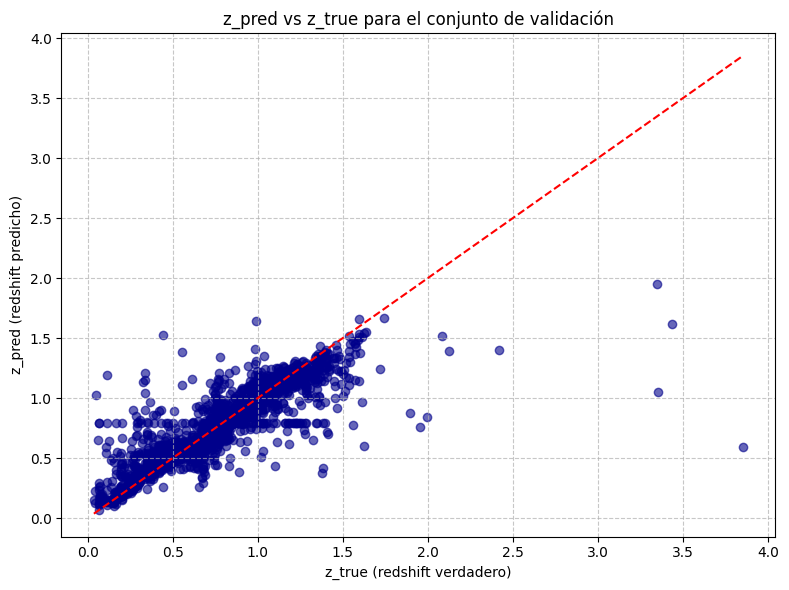

In [ ]:
# gráfico de valores reales v/s predichos

fig = plt.figure(figsize=(8, 6))
plt.scatter(y_test_selection, y_pred_validation, alpha=0.6, color = "darkblue")
plt.plot([y_test_selection.min(), y_test_selection.max()], [y_test_selection.min(), y_test_selection.max()], 'r--')
plt.xlabel('z_true (redshift verdadero)')
plt.ylabel('z_pred (redshift predicho)')
plt.title('z_pred vs z_true para el conjunto de validación')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Hay una clara correspondencia, el gráfico sigue una relación lineal con una pendiente cercana al 1 (lo ideal).

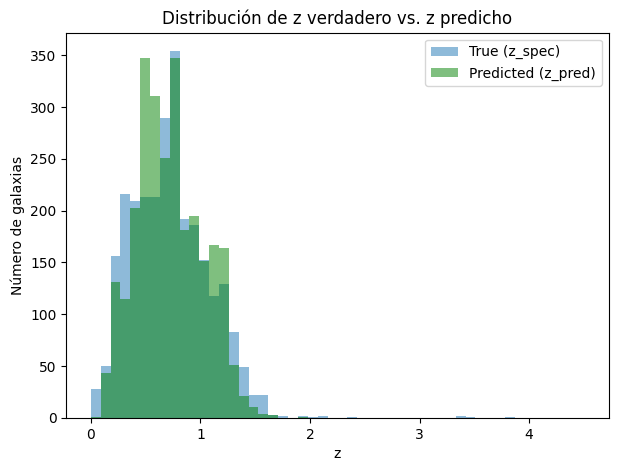

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(y_test_selection, bins=50, density=False, alpha=0.5, range=(0, y.max()), label='True (z_spec)')
plt.hist(y_pred_validation, bins=50, density=False, alpha=0.5, range=(0, y.max()), color='g', label='Predicted (z_pred)')
plt.xlabel('z')
plt.ylabel('Número de galaxias')
plt.legend()
plt.title('Distribución de z verdadero vs. z predicho')
plt.show()

En el histograma observamos que la distribución de predicciones resulta ser más estrecha que los valores observados.

Reportamos la siguiente tabla resumen:

| Modelo        | Features usadas | Hiperparámetros principales | MSE train | MSE validación |
| ------------- | --------------- | --------------------------- | --------- | -------------- |
| Decision Tree | Bandas u, g, r, i, z; colores u-g, g-r, i-z, i2-z       |  min_samples_split, max_depth, min_samples_leaf                              | 0.0270          |   0.0457             |
| Ensemble  (Random Forest)     |   Bandas u, g, r, i, z; colores u-g, g-r, i-z, i2-z               |    min_samples_split, max_depth, min_samples_lead, n_estimators                   | 0.0167|0.0308

## Respuestas


1. El modelo que obtuvo menor MSE en validación fue RandomForest con un 0.0308
 en comparación al 0.0457 del modelo baseline.

2. RandomForest fue elegido como el modelo final. Esto debido principalmente a la diferencia de 0.0149 en MSE; lo que se espera dada la diferencia en robustez de ambos métodos, con RandomForest trabajando con las predicciones de múltiples árboles.

3. Además de las diferencias entre MSE de validación mencionadas previamente, también existen diferencias entre los MSE de entrenamiento, con 0.0270 para el árbol único y 0.0167 para RandomForest. Esto además de las otras diferencias claras en cuanto a metodología: el método de ensamble entrena con conjuntos ligeramente distintos y con subconjuntos aleatorios.

4. Según los gráficos de feature importance, las variables más importantes corresponden a los colores u-g, i-z y g-r.  Esto tiene sentido si se aborda desde la perspectiva astronómica. Los colores se obtienen restando las magnitudes individuales en cada banda, lo que en astronomía permite extraer información sobre la forma o pendiente de la distribución recibida. Sumado a esto, la luz recibida desde las galaxias tampoco suele ser uniforme (como con el salto de 4000 Å), lo que el color encapsula de buena manera con las pendientes.

5. Ahora, para evaluar la importancia de las variables utilizadas, se utiliza Permutacion Importance y MDI:

i-z           0.526570
g-r           0.498452
u-g           0.460448
i2-z          0.049179
r_apercor     0.036310
g_apercor     0.026018
z_apercor     0.014108
i_apercor     0.013339
i2_apercor    0.009747
u_apercor     0.004953
dtype: float64


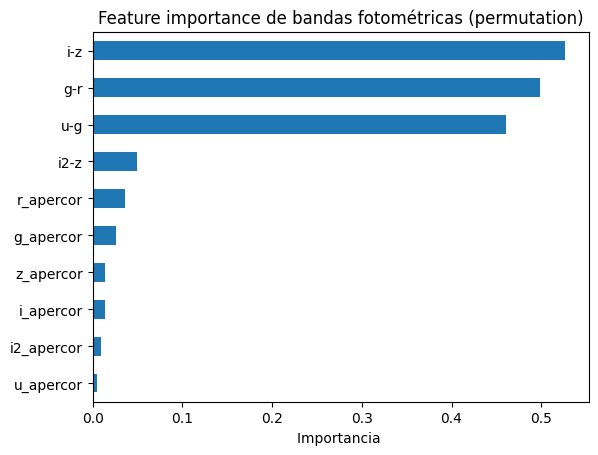

In [ ]:
# permutation importance
from sklearn.inspection import permutation_importance
permutation = permutation_importance(best_model_randomizer, X_test_selection,
                                     y_test_selection, n_repeats=10, random_state=42)
importancias_permutation = pd.Series(permutation.importances_mean, index=X_test_selection.columns).sort_values(ascending=False)
print(importancias_permutation)

importancias_permutation.plot(kind='barh')
plt.xlabel('Importancia ')
plt.title('Feature importance de bandas fotométricas (permutation)')
plt.gca().invert_yaxis()
plt.show()

u-g           0.355172
i-z           0.307629
g-r           0.193066
i2-z          0.041077
r_apercor     0.023184
g_apercor     0.022138
i2_apercor    0.015318
i_apercor     0.014790
u_apercor     0.013902
z_apercor     0.013725
dtype: float64


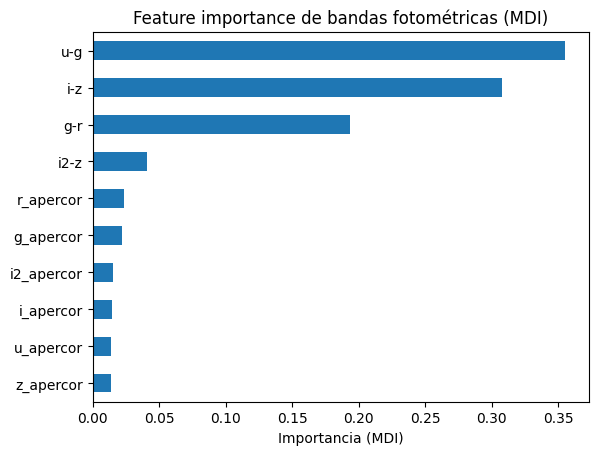

In [ ]:
# feature importance con MDI

importancias = pd.Series(best_model_randomizer.feature_importances_,
                         index=X_test_selection.columns).sort_values(ascending=False)
print(importancias)

importancias.plot(kind='barh')
plt.xlabel('Importancia (MDI)')
plt.title('Feature importance de bandas fotométricas (MDI)')
plt.gca().invert_yaxis()
plt.show()

No coinciden exactamente en el ranking, sin embargo, confirman que las variables más importantes corresponden a los colores *i-z*, *g-r* y *u-g*, intercambiando puestos según el criterio. La diferencia radica en cómo funciona cada uno: MDI se fija en qué variable fué más relevante para el árbol y Permutation importance en qué tanto error tendríamos si dejaramos una determinada variable de lado. *u-g* parece tener una mayor importancia al hacer los cortes en el árbol, pero *i-z* para determinar los resultados finales del modelo.

6. A partir del gráfico de redshift predichos vs redshift verdaderos, se extrae que el rango que va de 1.0 a 1.5 en los redshift reales posee una mayor dispersión de los datos, que tienden a alejarse de la recta. Además, se visualizan outliers después del valor 3.0 para los redshift reales, los que podrían ser objetos muy particulares o algún ruido en la medición.

7. Sí, en el scatter se observa el mismo efecto que "estrecha" la distribución de predicciones, con una pendiente levemente menor. Confirmamos esto al visualizar el histograma de la distribución, con la distribución de predicciones siendo más estrecha que la real. En el scatter se observa que el modelo tiene dificultades para predecir redshift mayores a 3.0, subestimado los datos, y también tiene dificultades alrededor de 0.2, sobreestimando los datos por sobre el valor real al encontrarse por sobre la linea.

8. No se utilizó OOB en este procedimiento, principalmente dado que no existe un OOB en árbol simple y se podrían estar comparando diferentes tipos de errores.

9. Un sesgo considerable es que sólo usamos fotométricas e ignoramos variables como la ascensión recta y declinación de los objetos. Si bien confiamos, debido a nuestros conocimientos previos, que los datos más importantes son los fotométricos, reconocemos que esto es un sesgo, y no descartamos que pueda ser una fuente de errores en el modelo.
10. La decisión que más impacto tuvo en los resultados, independientemente del modelo utilizado, fue la limpieza de datos. Al seleccionar los valores de redshift altamente confiables (calidad $\geq$ 3) el valor del MSE bajó considerablemente en todos los modelos probados.
11. Creemos que no necesariamente. En principio, un menor MSE debería indicar que el modelo es mejor. Pero desde el punto de vista científico, esta no es la realidad: el quehacer en la ciencia suele evidenciar que el desarrollo de un modelo siempre puede estar sometido a posibles errores de medición, sesgos por decisiones importantes al momento de pulir los datos, arbitrariedades en las elecciones de los parámetros, o error humano directo al momento de calcular los datos. Por eso resulta de vital importancia no solo quedarse con el MSE, sino que también con la manera en que se llevan a cabo las investigaciones.

## Conclusión

El estudio de redshift fotométricos con las herramientas de Machine Learning se presenta como una alternativa sencilla y eficaz al momento de buscar las predicciones correctas. En este trabajo se evidenció que las técnicas de limpieza de datos y el entrenamiento de modelos se adapta sin dificultades a problemas en el ámbito de la astrofísica.

Además, al entrenar tanto un árbol de decisión como un método de ensamble, es posible comparar las limitaciones de cada manera al momento de abordar un determinado problema. En esta oportunidad, los resultados reflejan una mayor capacidad predictiva para el método Random Forest Regressor, con un MSE de 	0.0308 en validación frente al 0.0457 en validación para el árbol único.

En algún trabajo futuro, estas métricas podrían mejorarse con alguna capacidad de cómputo mayor que permita entrenar varios modelos y sus hiperparámetros en paralelo, y con el acceso a mayor información en cuanto a la obtención de los datos y lo que representan.
